# 1. Verifica della Qualità (Data Cleaning)
- Cercare valori mancanti (NaN)
- Usare `.info()` e `.describe()` di pandas

In [83]:
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

In [84]:
# Copper HG=F
tiker_copper_symbol = "HG=F"
# Create a ticker object
ticker_copper = yf.Ticker(tiker_copper_symbol)
# data for the last year
coppere_data = ticker_copper.history(period="1y")
print("--- DATA HEAD ---")
print(coppere_data.head())
print("\n--- DATA INFO ---")
print(coppere_data.info())
print("\n--- DATA DESCRIBE ---")
print(coppere_data.describe())

--- DATA HEAD ---
                             Open    High     Low   Close  Volume  Dividends  \
Date                                                                           
2025-03-03 00:00:00-05:00  4.5445  4.6160  4.5080  4.5765    1408        0.0   
2025-03-04 00:00:00-05:00  4.5660  4.5670  4.5000  4.5275    1394        0.0   
2025-03-05 00:00:00-05:00  4.5350  4.7900  4.5350  4.7665     819        0.0   
2025-03-06 00:00:00-05:00  4.7815  4.8025  4.7225  4.7790    1108        0.0   
2025-03-07 00:00:00-05:00  4.7520  4.7560  4.6570  4.6830     903        0.0   

                           Stock Splits  
Date                                     
2025-03-03 00:00:00-05:00           0.0  
2025-03-04 00:00:00-05:00           0.0  
2025-03-05 00:00:00-05:00           0.0  
2025-03-06 00:00:00-05:00           0.0  
2025-03-07 00:00:00-05:00           0.0  

--- DATA INFO ---
<class 'pandas.DataFrame'>
DatetimeIndex: 252 entries, 2025-03-03 00:00:00-05:00 to 2026-03-02 00:00:00-05:0

---

## Multi asset analysis

In [85]:
# Download multi asset data
assets = ["HG=F", "DX-Y.NYB", "CL=F"]
raw_data = yf.download(assets, period="1y")

[*********************100%***********************]  3 of 3 completed


In [86]:
raw_data.head()
raw_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 253 entries, 2025-03-03 to 2026-03-02
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, CL=F)       252 non-null    float64
 1   (Close, DX-Y.NYB)   252 non-null    float64
 2   (Close, HG=F)       252 non-null    float64
 3   (High, CL=F)        252 non-null    float64
 4   (High, DX-Y.NYB)    252 non-null    float64
 5   (High, HG=F)        252 non-null    float64
 6   (Low, CL=F)         252 non-null    float64
 7   (Low, DX-Y.NYB)     252 non-null    float64
 8   (Low, HG=F)         252 non-null    float64
 9   (Open, CL=F)        252 non-null    float64
 10  (Open, DX-Y.NYB)    252 non-null    float64
 11  (Open, HG=F)        252 non-null    float64
 12  (Volume, CL=F)      252 non-null    float64
 13  (Volume, DX-Y.NYB)  252 non-null    float64
 14  (Volume, HG=F)      252 non-null    float64
dtypes: float64(15)
memory usage: 31.6 KB


---

# pulizia dei dati
- Prendo solo i prezzi di chiusura `Close`
- 252/253 righe non-null, `dropna` per eliminare la riga con valore negativo

In [87]:
# create copy, do not to use a view
close_price = raw_data["Close"].copy()
close_price.columns = ["Copper", "USD", "Crude_Oil"]
close_price = close_price.dropna()
close_price.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-03-03 to 2026-03-02
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Copper     251 non-null    float64
 1   USD        251 non-null    float64
 2   Crude_Oil  251 non-null    float64
dtypes: float64(3)
memory usage: 7.8 KB


### Risultati
1. Solo prezzi di chiusura
2. 251 righe non-null (Ogni riga avava un `NaN`, ma `non la stessa riga`)

---

## Matrice di correlazione

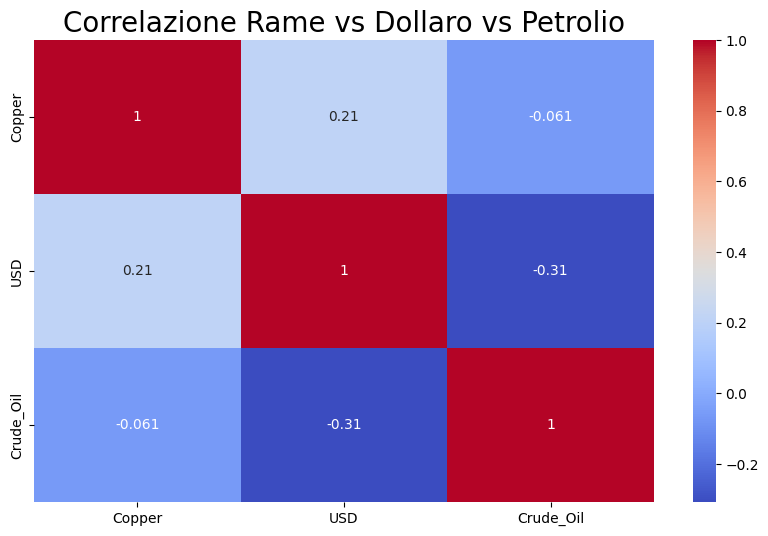

In [88]:
corr_matrix = close_price.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlazione Rame vs Dollaro vs Petrolio", size=20)
plt.show()

### Risultati
Sembra non esserci correlazione
Possibili cause:
- Le materie vengono influenzate successivamente (c'è un lag)
- Le variazioni dei prezzi grezzi non sono significative (devo usare la variazione percentuale)

---

## Variazione percentuale
Calcolo le differenze percentuali *per confrontare mele con mele*

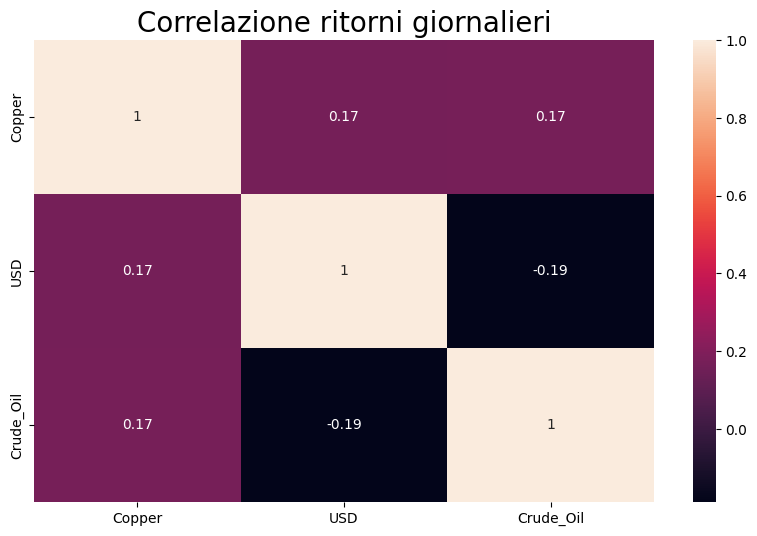

In [89]:
# daily returns
df_returns = close_price.pct_change().dropna()
returns_correlation_matrix = df_returns.corr()
plt.figure(figsize=(10,6))
sns.heatmap(returns_correlation_matrix, annot=True)
plt.title("Correlazione ritorni giornalieri", size=20)
plt.show()

### Results
Correlazioni ancora molto deboli
Possibili cause:
- Lag

---

## I conti non tornano
Vediamo con dei grafici cosa sta succedendo
Con `regoplot` vediamo:
- Scatter plot (punti)
- Regreessione lineare (linea)
- Intervallo di confidenza al 95% (ombra)

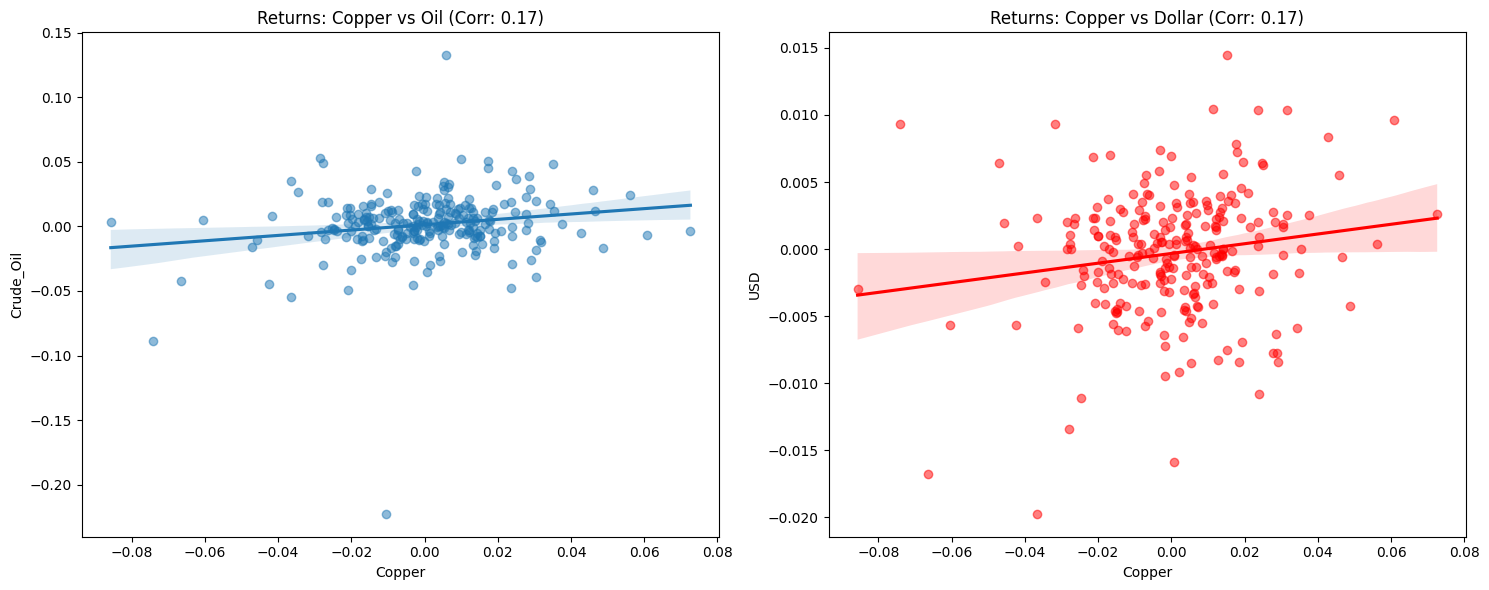

In [90]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Rame vs Petrolio
sns.regplot(x=df_returns['Copper'], y=df_returns['Crude_Oil'], ax=ax1, scatter_kws={'alpha':0.5})
ax1.set_title(f'Returns: Copper vs Oil (Corr: {df_returns.corr().iloc[0,2]:.2f})')

# Rame vs Dollaro
sns.regplot(x=df_returns['Copper'], y=df_returns['USD'], ax=ax2, scatter_kws={'alpha':0.5}, color='red')
ax2.set_title(f'Returns: Copper vs Dollar (Corr: {df_returns.corr().iloc[0,1]:.2f})')

plt.tight_layout()
plt.show()

## Risultati
1. Il fatto che la nuvola di punti sia dispersa e la linea di `regplot` sia quasi piatta ti dice che il mercato è efficiente.
2. Quei punti lontani dalla linea di regressione sono le anomalie. L'AI dovrà imparare a ignorare questi "botti" estemporanei per concentrarsi sul segnale sottostante.
3. Poiché il Dollaro di oggi non spiega il Rame di oggi, i dati suggeriscono che l'influenza potrebbe essere ritardata.

---

## Normalizzare i dati
Uso lo `StandardScaler` per standardizzare i risultati (1% potrebbe essere tanto per il dollaro e poco per il rame)

In [91]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Calcola media e STD e le applica, ritorna un array NumPy
scaled_values = scaler.fit_transform(df_returns)
df_scaled = pd.DataFrame(scaled_values, columns=df_returns.columns, index=df_returns.index) # type: ignore
# arrotondo a 2 cifre decimali
df_scaled.describe().round(2)

,Copper,USD,Crude_Oil
count,250.00,250.00,250.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-4.13,-4.25,-8.99
25%,-0.60,-0.50,-0.36
50%,0.02,0.07,0.02
75%,0.59,0.58,0.42
max,3.47,3.23,5.26


### Risultati
Ora l'algoritmo può capire se un asset fa un balzo eccellente o se è nella normalità

---

## Test & Train
Fare un passo indietro, bisogna dividere il dataset in 80-20 train-test

### `⚠️ N.B.` Fare il fit solo sul train, non fare cheat *sbirciando* sul test

In [101]:
# 80% della lunghezza
split_index = int(len(df_returns) * 0.8)

scaler = StandardScaler()

train_values = df_returns.iloc[:split_index]
test_values = df_returns.iloc[split_index:]

scaler.fit(train_values)

train_scaled = scaler.transform(train_values)
test_scaled = scaler.transform(test_values)

df_train_scaled = pd.DataFrame(train_scaled, columns=train_values.columns, index=train_values.index) # type: ignore
df_test_scaled = pd.DataFrame(test_scaled, columns=test_values.columns, index=test_values.index) # type: ignore

print("--- CORRELAZIONE TRAIN SET ---")
print(df_train_scaled.corr().round(3))

print("\n--- CORRELAZIONE TEST SET ---")
print(df_test_scaled.corr().round(3))

--- CORRELAZIONE TRAIN SET ---
           Copper    USD  Crude_Oil
Copper      1.000  0.210      0.179
USD         0.210  1.000     -0.183
Crude_Oil   0.179 -0.183      1.000

--- CORRELAZIONE TEST SET ---
           Copper    USD  Crude_Oil
Copper      1.000 -0.072      0.141
USD        -0.072  1.000     -0.227
Crude_Oil   0.141 -0.227      1.000
